# Customer Segmentation Analysis for Telecommunications

## Project Overview
This notebook implements customer segmentation using machine learning techniques to identify distinct customer groups based on their behavior, demographics, and usage patterns in the telecommunications industry.

## Business Objective
- Identify customer segments with different characteristics and behaviors
- Understand which segments are more likely to purchase certain services
- Provide actionable insights for targeted marketing and retention strategies
- Reduce customer churn by understanding customer needs better

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Additional preprocessing tools
# from category_encoders import TargetEncoder
import scipy.stats as stats

# Set style for visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

## 1. Data Loading and Initial Exploration

In [3]:
# Load the dataset
df = pd.read_csv('../data/telecom_customer_churn.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nDataset info:")
df.info()

Dataset shape: (7043, 21)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

In [4]:
# Display first few rows
display(df.head())

# Basic statistics
print("\nBasic Statistics:")
display(df.describe())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Basic Statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

# Check unique values for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

Missing Values:
Series([], dtype: int64)

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

Pap

## 2. Data Cleaning and Preprocessing

### Challenge 1: Mixed Data Types
The dataset contains both numerical and categorical features. We need to handle them appropriately for machine learning algorithms.

In [6]:
# Create a copy for preprocessing
df_clean = df.copy()

# Challenge: TotalCharges column is object type but should be numeric
print(f"TotalCharges data type: {df_clean['TotalCharges'].dtype}")
print(f"Sample TotalCharges values: {df_clean['TotalCharges'].head()}")

# Check for non-numeric values
non_numeric = df_clean[df_clean['TotalCharges'] == ' ']
print(f"\nRows with empty TotalCharges: {len(non_numeric)}")

# Solution: Convert to numeric and handle empty strings
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(' ', np.nan)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'])

# For customers with NaN TotalCharges, we can infer it might be new customers
# Let's check their tenure
print(f"\nTenure for customers with missing TotalCharges:")
print(df_clean[df_clean['TotalCharges'].isna()]['tenure'].describe())

TotalCharges data type: object
Sample TotalCharges values: 0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

Rows with empty TotalCharges: 11

Tenure for customers with missing TotalCharges:
count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64


In [7]:
# Solution for missing TotalCharges: Use MonthlyCharges * tenure for estimation
mask = df_clean['TotalCharges'].isna()
df_clean.loc[mask, 'TotalCharges'] = df_clean.loc[mask, 'MonthlyCharges'] * df_clean.loc[mask, 'tenure']

print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")
print(f"TotalCharges data type after cleaning: {df_clean['TotalCharges'].dtype}")

Missing values after cleaning: 0
TotalCharges data type after cleaning: float64


Numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


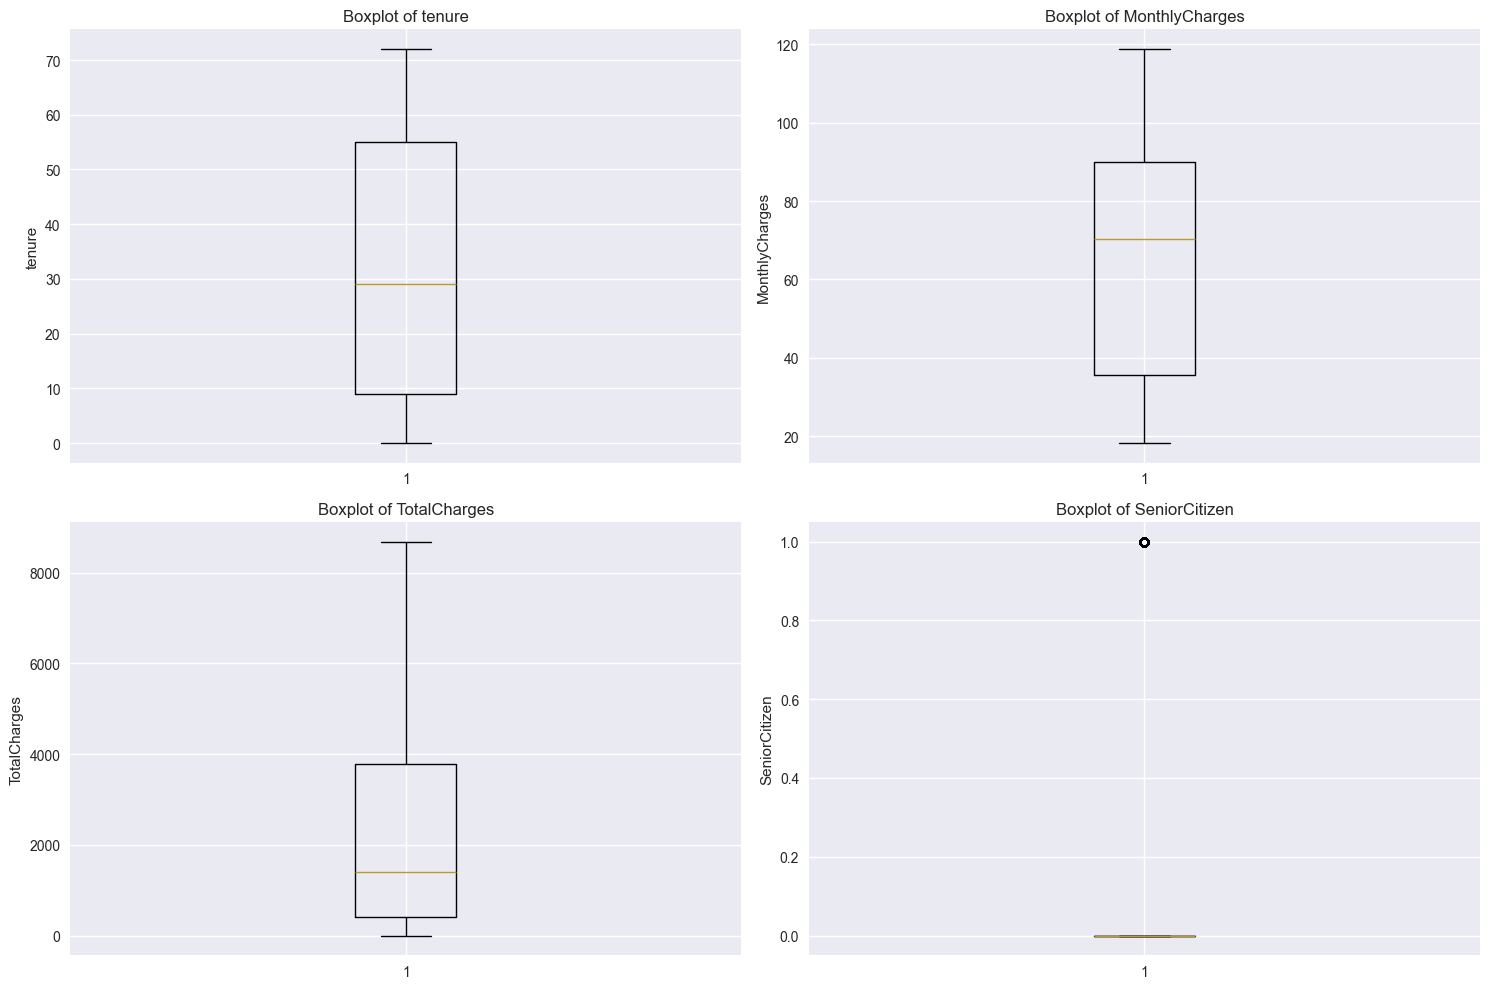

In [8]:
# Identify numerical and categorical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_cols = [col for col in df_clean.columns if col not in numerical_cols + ['customerID']]

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Check for outliers in numerical columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('../visualizations/outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### Challenge 2: Handling Categorical Variables
We have multiple categorical variables with different cardinalities that need proper encoding for ML algorithms.

In [9]:
# Analyze categorical variables
print("Categorical Variable Analysis:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df_clean[col].nunique()}")
    print(f"  Values: {df_clean[col].unique()}")
    print(f"  Value counts:")
    print(df_clean[col].value_counts())

Categorical Variable Analysis:

gender:
  Unique values: 2
  Values: ['Female' 'Male']
  Value counts:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
  Unique values: 2
  Values: ['Yes' 'No']
  Value counts:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
  Unique values: 2
  Values: ['No' 'Yes']
  Value counts:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
  Unique values: 2
  Values: ['No' 'Yes']
  Value counts:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
  Unique values: 3
  Values: ['No phone service' 'No' 'Yes']
  Value counts:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
  Unique values: 3
  Values: ['DSL' 'Fiber optic' 'No']
  Value counts:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
  Unique values: 3
  Va

In [10]:
# Create feature engineering pipeline
def create_features(df):
    """Create additional features for better segmentation"""
    df_featured = df.copy()
    
    # Create tenure groups
    df_featured['tenure_group'] = pd.cut(df_featured['tenure'], 
                                        bins=[0, 12, 24, 36, 48, 100], 
                                        labels=['0-12', '13-24', '25-36', '37-48', '49+'])
    
    # Create monthly charges groups
    df_featured['monthly_charges_group'] = pd.cut(df_featured['MonthlyCharges'], 
                                                 bins=4, 
                                                 labels=['Low', 'Medium', 'High', 'Very High'])
    
    # Create total charges groups
    df_featured['total_charges_group'] = pd.cut(df_featured['TotalCharges'], 
                                               bins=4, 
                                               labels=['Low', 'Medium', 'High', 'Very High'])
    
    # Average monthly charge (total/tenure)
    df_featured['avg_monthly_charge'] = df_featured['TotalCharges'] / (df_featured['tenure'] + 1)
    
    # Create service count (total number of services)
    service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    
    df_featured['total_services'] = 0
    for col in service_cols:
        if col == 'InternetService':
            df_featured['total_services'] += (df_featured[col] != 'No').astype(int)
        else:
            df_featured['total_services'] += (df_featured[col] == 'Yes').astype(int)
    
    # Create internet user flag
    df_featured['has_internet'] = (df_featured['InternetService'] != 'No').astype(int)
    
    # Create phone user flag
    df_featured['has_phone'] = (df_featured['PhoneService'] == 'Yes').astype(int)
    
    return df_featured

df_featured = create_features(df_clean)
print(f"Features after engineering: {df_featured.shape[1]}")
print(f"New features created: {[col for col in df_featured.columns if col not in df_clean.columns]}")

Features after engineering: 28
New features created: ['tenure_group', 'monthly_charges_group', 'total_charges_group', 'avg_monthly_charge', 'total_services', 'has_internet', 'has_phone']


## 3. Exploratory Data Analysis (EDA)

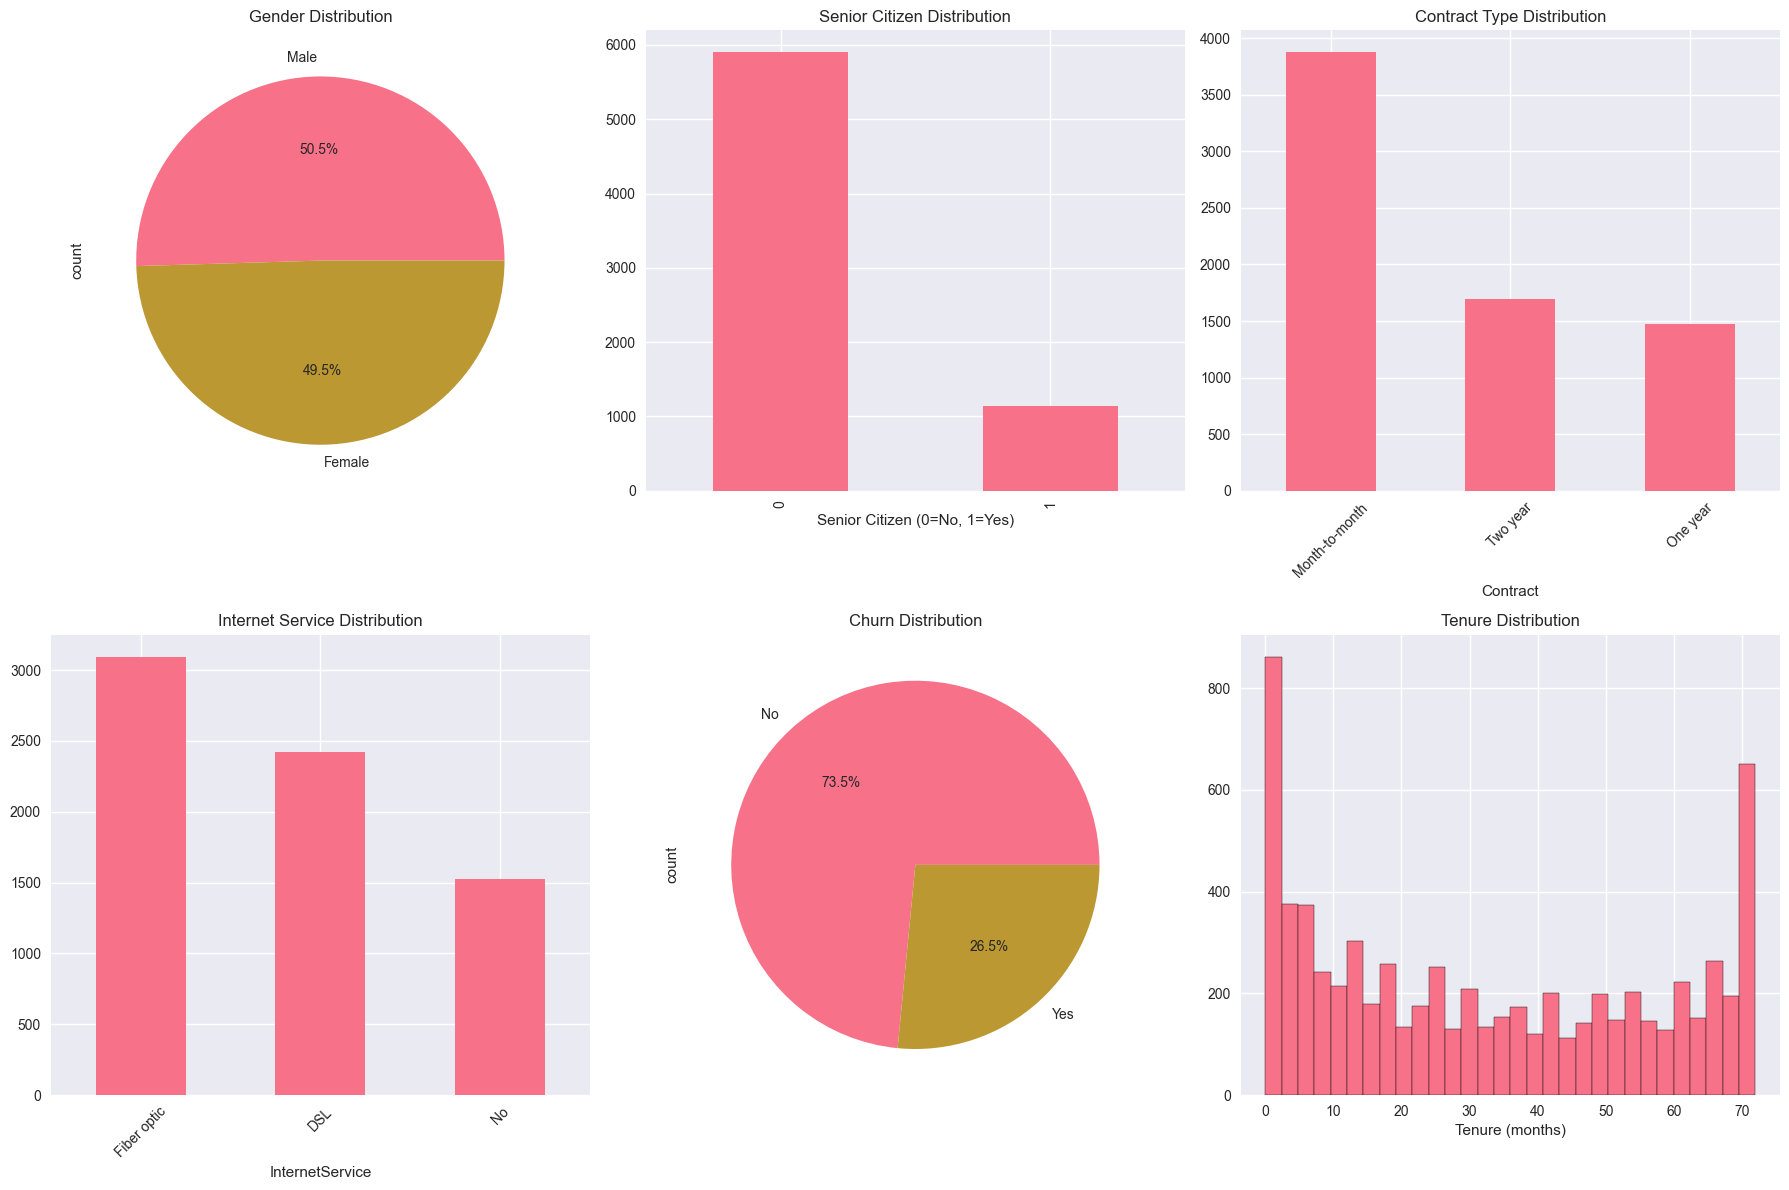

In [11]:
# Customer distribution analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Gender distribution
df_featured['gender'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('Gender Distribution')

# Senior Citizen distribution
df_featured['SeniorCitizen'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Senior Citizen Distribution')
axes[1].set_xlabel('Senior Citizen (0=No, 1=Yes)')

# Contract type distribution
df_featured['Contract'].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_title('Contract Type Distribution')
axes[2].tick_params(axis='x', rotation=45)

# Internet Service distribution
df_featured['InternetService'].value_counts().plot(kind='bar', ax=axes[3])
axes[3].set_title('Internet Service Distribution')
axes[3].tick_params(axis='x', rotation=45)

# Churn distribution
df_featured['Churn'].value_counts().plot(kind='pie', ax=axes[4], autopct='%1.1f%%')
axes[4].set_title('Churn Distribution')

# Tenure distribution
axes[5].hist(df_featured['tenure'], bins=30, edgecolor='black')
axes[5].set_title('Tenure Distribution')
axes[5].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.savefig('../visualizations/customer_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

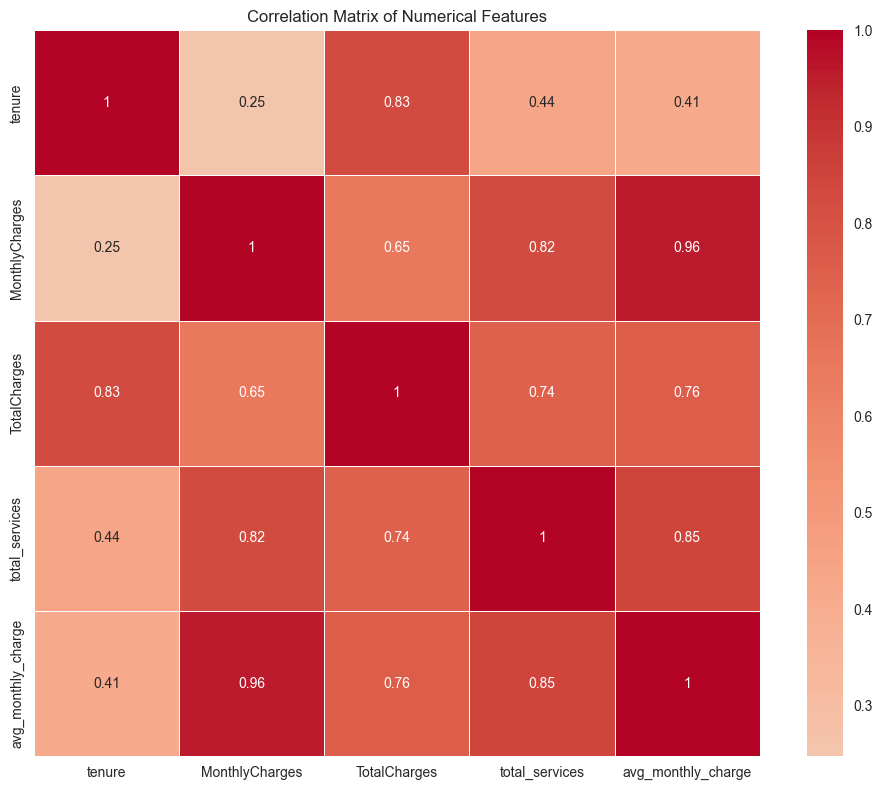

In [12]:
# Correlation analysis for numerical features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'avg_monthly_charge']
correlation_matrix = df_featured[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('../visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

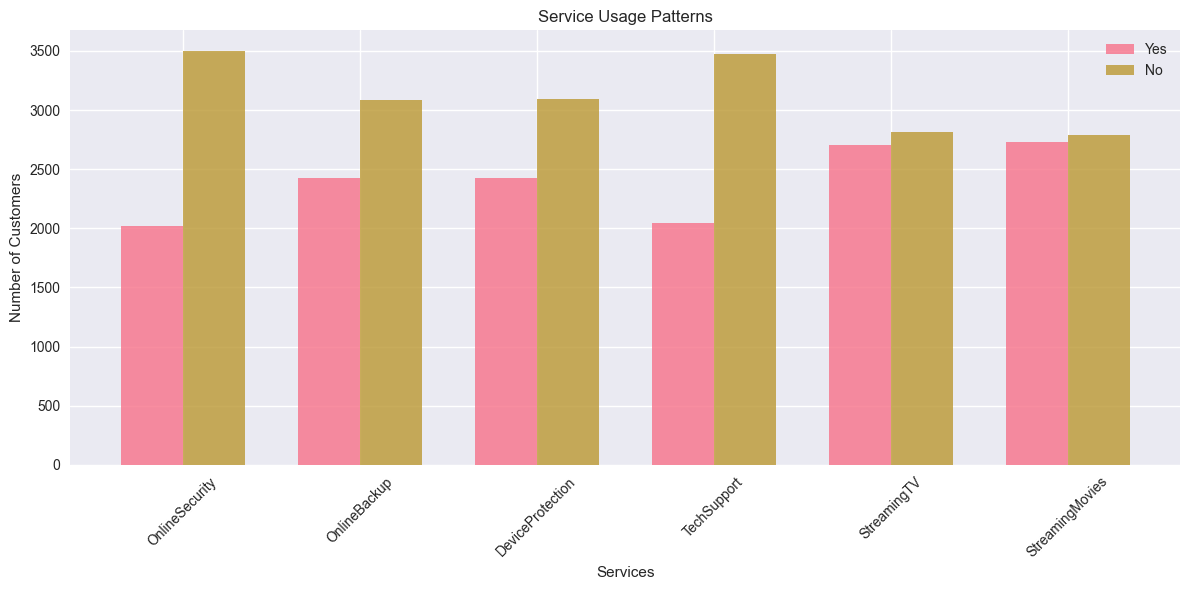

In [13]:
# Service usage patterns
service_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

service_data = []
for service in service_columns:
    yes_count = (df_featured[service] == 'Yes').sum()
    no_count = (df_featured[service] == 'No').sum()
    service_data.append([service, yes_count, no_count])

service_df = pd.DataFrame(service_data, columns=['Service', 'Yes', 'No'])

plt.figure(figsize=(12, 6))
x = np.arange(len(service_columns))
width = 0.35

plt.bar(x - width/2, service_df['Yes'], width, label='Yes', alpha=0.8)
plt.bar(x + width/2, service_df['No'], width, label='No', alpha=0.8)

plt.xlabel('Services')
plt.ylabel('Number of Customers')
plt.title('Service Usage Patterns')
plt.xticks(x, service_columns, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/service_usage_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing for Machine Learning

### Challenge 3: Creating a Pipeline for Mixed Data Types
We need to handle numerical and categorical features differently while maintaining the ability to inverse transform for interpretation.

In [14]:
# Prepare data for machine learning
# Exclude ID and target variable for clustering
features_for_clustering = df_featured.drop(['customerID'], axis=1)

# Separate features by type
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 
                     'total_services', 'avg_monthly_charge', 'has_internet', 'has_phone']

categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                       'PaperlessBilling', 'PaymentMethod']

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numerical features (8): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'total_services', 'avg_monthly_charge', 'has_internet', 'has_phone']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [15]:
# Create preprocessing pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

# Fit and transform the data
X_processed = preprocessor.fit_transform(features_for_clustering)

# Get feature names after preprocessing
feature_names = (numerical_features + 
                list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))

print(f"Shape after preprocessing: {X_processed.shape}")
print(f"Total features after one-hot encoding: {len(feature_names)}")

# Create DataFrame for easier handling
X_df = pd.DataFrame(X_processed, columns=feature_names)
print(f"\nFirst few feature names: {feature_names[:10]}")
print(f"Last few feature names: {feature_names[-10:]}")

Shape after preprocessing: (7043, 34)
Total features after one-hot encoding: 34

First few feature names: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'total_services', 'avg_monthly_charge', 'has_internet', 'has_phone', 'gender_Male', 'Partner_Yes']
Last few feature names: ['StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 5. Dimensionality Reduction for Visualization

Explained variance ratio: [0.42916157 0.14380622]
Total explained variance: 0.573


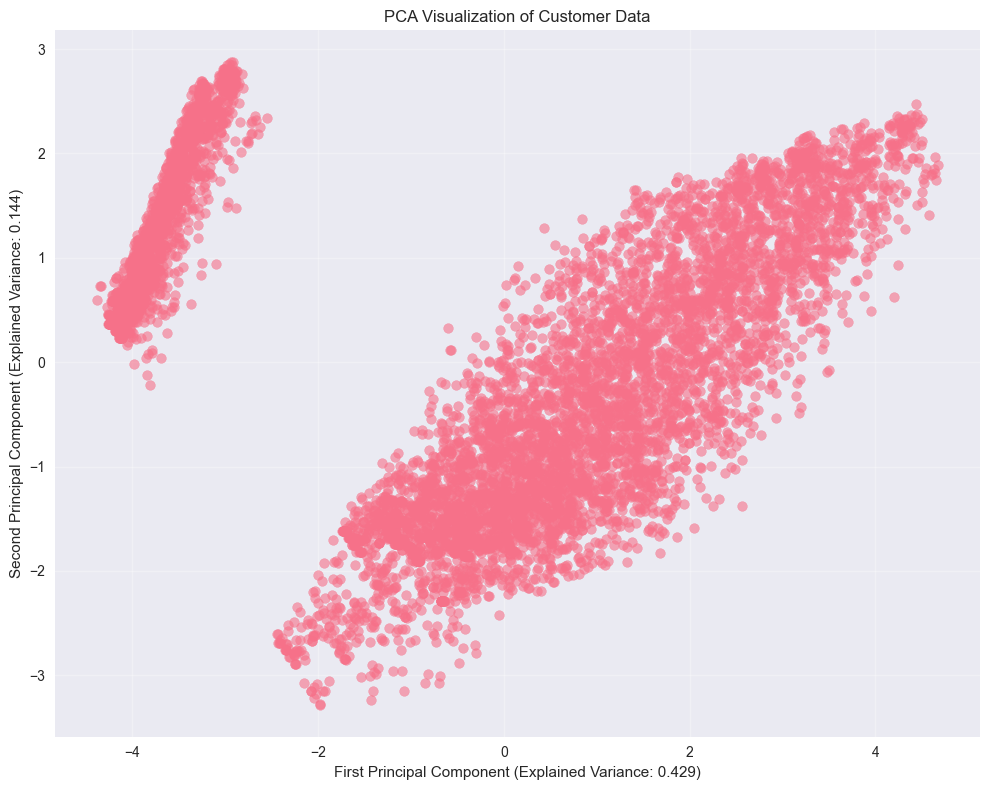

In [16]:
# Apply PCA for dimensionality reduction and visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.3f}")

# Plot PCA components
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.xlabel(f'First Principal Component (Explained Variance: {pca.explained_variance_ratio_[0]:.3f})')
plt.ylabel(f'Second Principal Component (Explained Variance: {pca.explained_variance_ratio_[1]:.3f})')
plt.title('PCA Visualization of Customer Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Customer Segmentation with Multiple Algorithms

### Challenge 4: Choosing Optimal Number of Clusters
We'll use multiple methods to determine the best number of clusters.

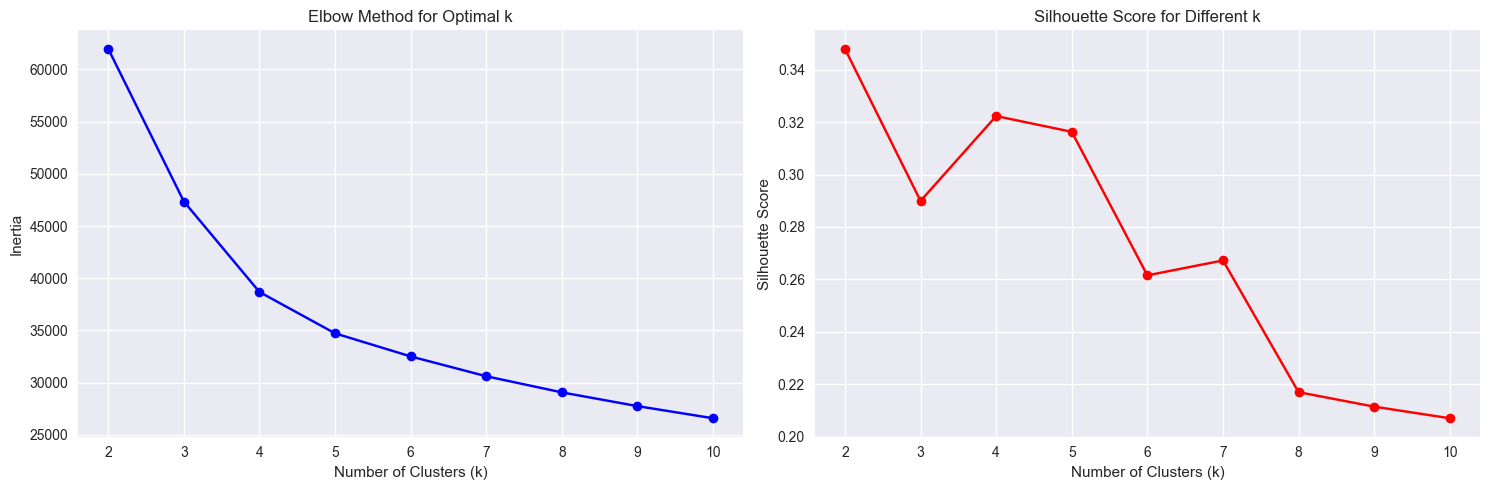

Optimal number of clusters based on silhouette score: 2
Silhouette scores: {2: 0.34795953352459374, 3: 0.28993134519540414, 4: 0.3223280533379985, 5: 0.31630871772862373, 6: 0.2615409853043281, 7: 0.26722130892698964, 8: 0.2169630807059822, 9: 0.21143340849005304, 10: 0.20700458068642133}


In [17]:
# Determine optimal number of clusters using Elbow Method and Silhouette Score
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_))

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

# Silhouette scores
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Different k')
ax2.grid(True)

plt.tight_layout()
plt.savefig('../visualizations/cluster_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# Find optimal k
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")
print(f"Silhouette scores: {dict(zip(k_range, silhouette_scores))}")

In [18]:
# Apply K-Means clustering with optimal k
optimal_k = 4  # Based on analysis above or business requirements

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_processed)

# Add cluster labels to original dataframe
df_clustered = df_featured.copy()
df_clustered['Cluster'] = cluster_labels

print(f"Clustering completed with {optimal_k} clusters")
print(f"Silhouette Score: {silhouette_score(X_processed, cluster_labels):.3f}")
print(f"\nCluster distribution:")
print(df_clustered['Cluster'].value_counts().sort_index())

Clustering completed with 4 clusters
Silhouette Score: 0.322

Cluster distribution:
Cluster
0     682
1    1526
2    2149
3    2686
Name: count, dtype: int64


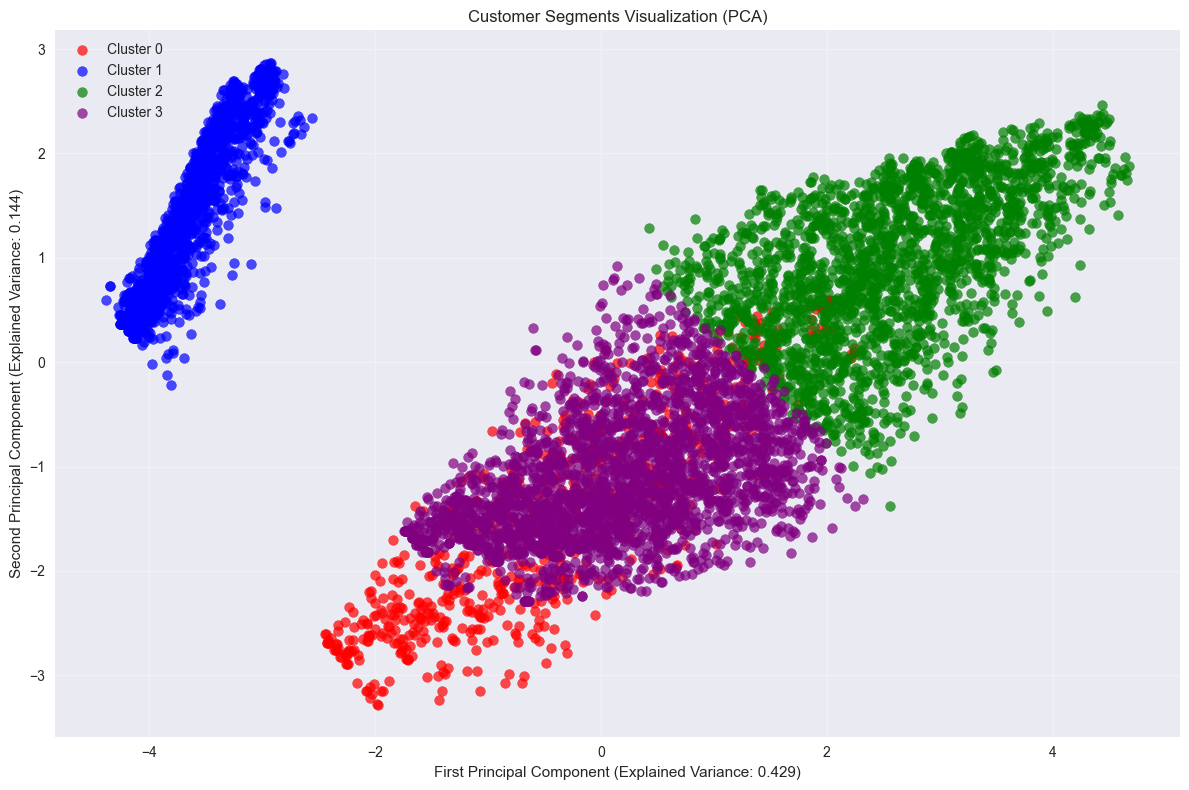

In [19]:
# Visualize clusters using PCA
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(optimal_k):
    cluster_points = X_pca[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=colors[i], label=f'Cluster {i}', alpha=0.7, s=50)

plt.xlabel(f'First Principal Component (Explained Variance: {pca.explained_variance_ratio_[0]:.3f})')
plt.ylabel(f'Second Principal Component (Explained Variance: {pca.explained_variance_ratio_[1]:.3f})')
plt.title('Customer Segments Visualization (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/customer_segments_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Cluster Analysis and Profiling

In [20]:
# Analyze cluster characteristics
def analyze_clusters(df, cluster_col='Cluster'):
    """Comprehensive cluster analysis"""
    
    print("=" * 60)
    print("CLUSTER PROFILING ANALYSIS")
    print("=" * 60)
    
    # Numerical features analysis
    numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']
    
    cluster_profiles = df.groupby(cluster_col)[numerical_cols].agg(['mean', 'median', 'std']).round(2)
    
    print("\nNUMERICAL FEATURES BY CLUSTER:")
    display(cluster_profiles)
    
    # Categorical features analysis
    categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 
                       'InternetService', 'Churn']
    
    for col in categorical_cols:
        print(f"\n{col.upper()} DISTRIBUTION BY CLUSTER:")
        cluster_cat = pd.crosstab(df[cluster_col], df[col], normalize='index') * 100
        display(cluster_cat.round(1))
    
    return cluster_profiles

cluster_analysis = analyze_clusters(df_clustered)

CLUSTER PROFILING ANALYSIS

NUMERICAL FEATURES BY CLUSTER:


tenure               MonthlyCharges               TotalCharges  \
          mean median    std           mean median    std         mean   
Cluster                                                                  
0        31.74   29.0  24.23          42.03  40.58  11.42      1496.03   
1        30.55   25.0  24.36          21.08  20.15   2.16       662.60   
2        55.93   59.0  14.06          93.19  95.25  14.30      5205.22   
3        14.72   11.0  13.41          72.61  74.40  15.85      1056.86   

                          total_services               
          median      std           mean median   std  
Cluster                                                
0        1149.03  1341.69           3.56    4.0  1.62  
1         519.20   555.63           1.00    1.0  0.00  
2        5138.10  1577.38           5.95    6.0  1.24  
3         810.70   930.50           3.53    3.0  1.19


GENDER DISTRIBUTION BY CLUSTER:


gender,Female,Male
Cluster,,
0,48.5,51.5
1,49.0,51.0
2,49.3,50.7
3,50.3,49.7



SENIORCITIZEN DISTRIBUTION BY CLUSTER:


...

Contract,Month-to-month,One year,Two year
Cluster,,,
0,55.1,21.3,23.6
1,34.3,23.9,41.8
2,28.7,32.1,39.3
3,87.8,10.2,1.9



INTERNETSERVICE DISTRIBUTION BY CLUSTER:


InternetService,DSL,Fiber optic,No
Cluster,,,
0,100.0,0.0,0.0
1,0.0,0.0,100.0
2,30.9,69.1,0.0
3,40.0,60.0,0.0



CHURN DISTRIBUTION BY CLUSTER:


Churn,No,Yes
Cluster,,
0,75.1,24.9
1,92.6,7.4
2,82.8,17.2
3,54.7,45.3


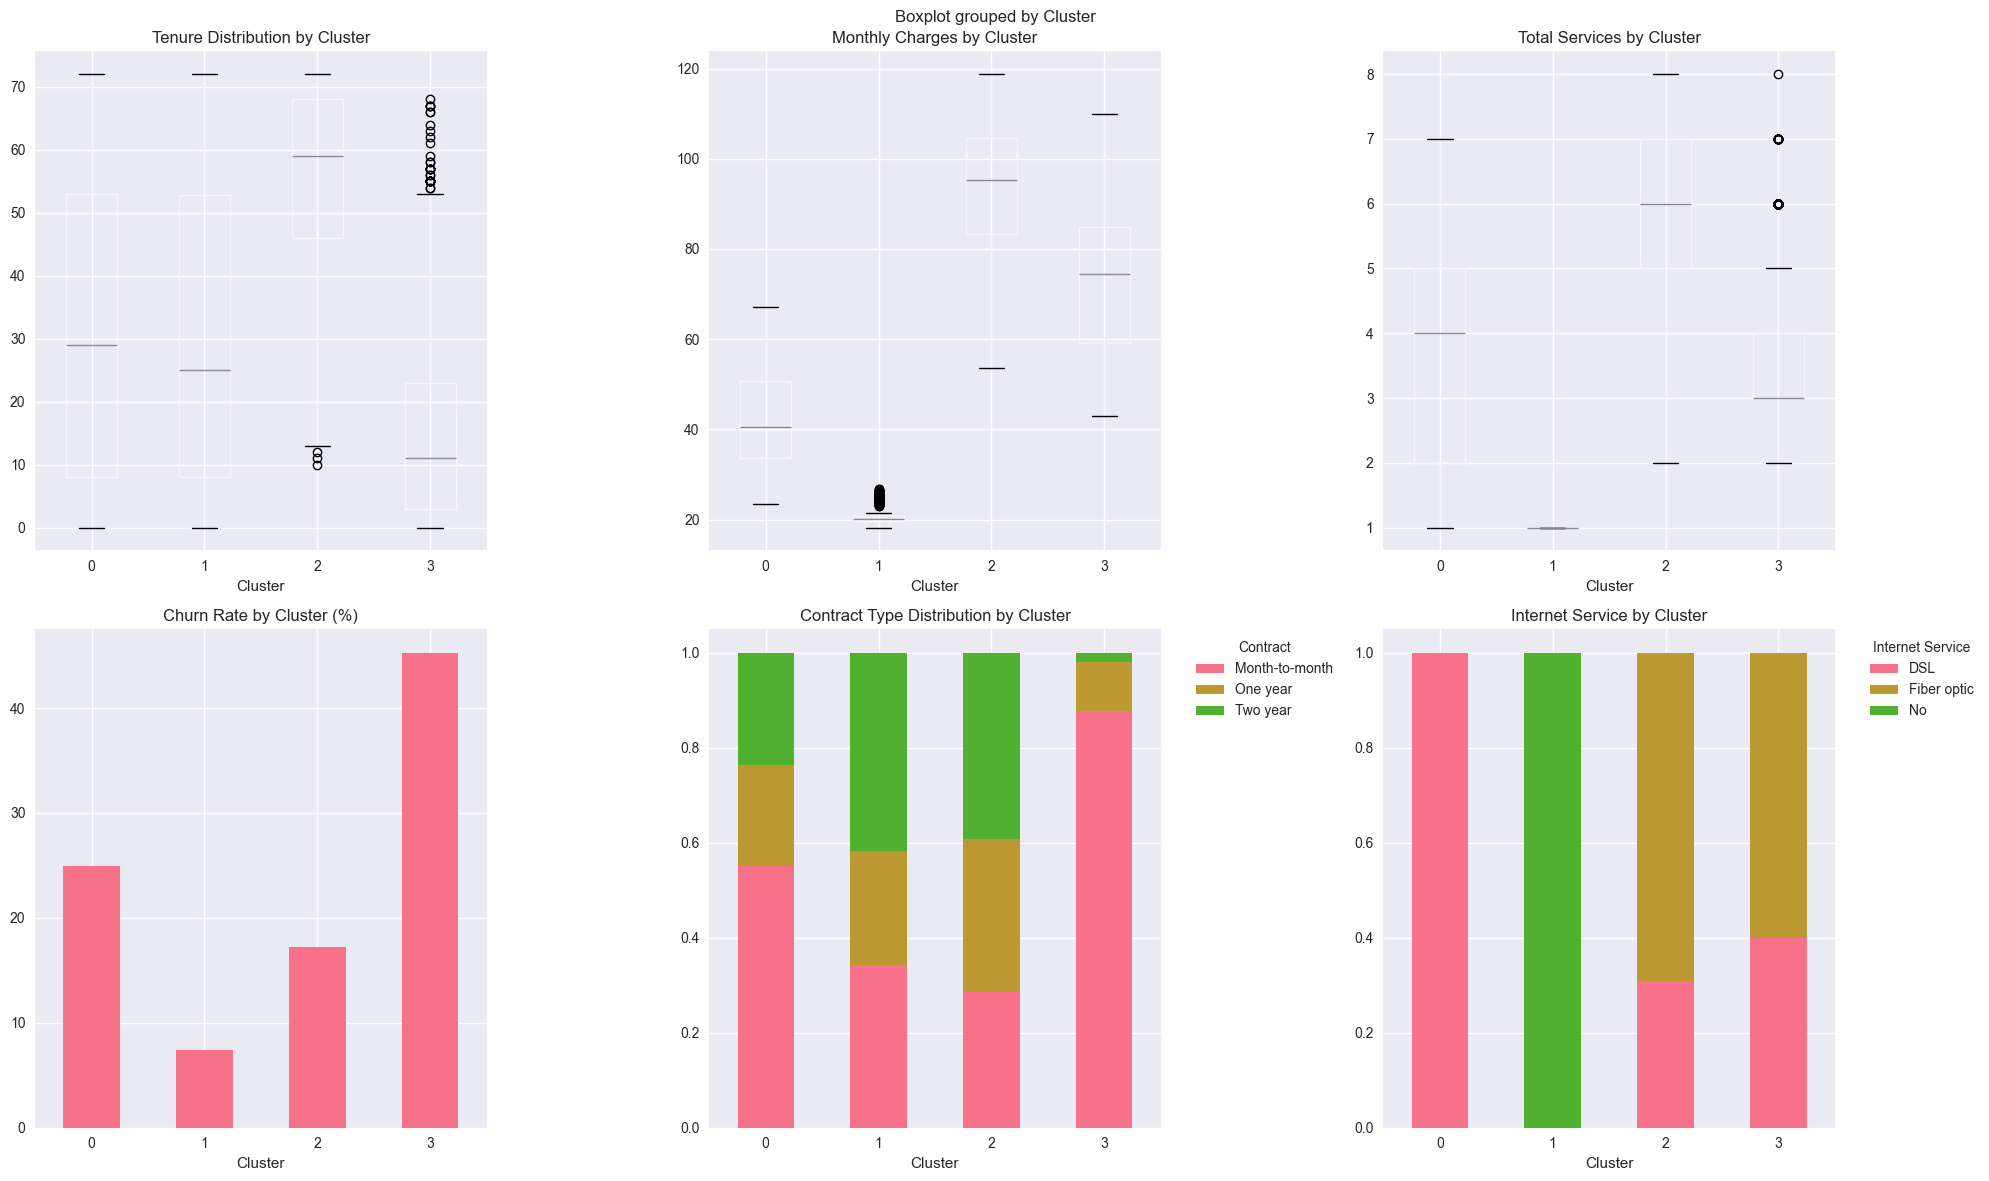

In [21]:
# Create comprehensive cluster visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

# 1. Tenure by cluster
df_clustered.boxplot(column='tenure', by='Cluster', ax=axes[0])
axes[0].set_title('Tenure Distribution by Cluster')
axes[0].set_xlabel('Cluster')

# 2. Monthly charges by cluster
df_clustered.boxplot(column='MonthlyCharges', by='Cluster', ax=axes[1])
axes[1].set_title('Monthly Charges by Cluster')
axes[1].set_xlabel('Cluster')

# 3. Total services by cluster
df_clustered.boxplot(column='total_services', by='Cluster', ax=axes[2])
axes[2].set_title('Total Services by Cluster')
axes[2].set_xlabel('Cluster')

# 4. Churn rate by cluster
churn_by_cluster = df_clustered.groupby('Cluster')['Churn'].apply(lambda x: (x=='Yes').mean()) * 100
churn_by_cluster.plot(kind='bar', ax=axes[3])
axes[3].set_title('Churn Rate by Cluster (%)')
axes[3].set_xlabel('Cluster')
axes[3].tick_params(axis='x', rotation=0)

# 5. Contract type by cluster
contract_cluster = pd.crosstab(df_clustered['Cluster'], df_clustered['Contract'], normalize='index')
contract_cluster.plot(kind='bar', stacked=True, ax=axes[4])
axes[4].set_title('Contract Type Distribution by Cluster')
axes[4].set_xlabel('Cluster')
axes[4].legend(title='Contract', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[4].tick_params(axis='x', rotation=0)

# 6. Internet service by cluster
internet_cluster = pd.crosstab(df_clustered['Cluster'], df_clustered['InternetService'], normalize='index')
internet_cluster.plot(kind='bar', stacked=True, ax=axes[5])
axes[5].set_title('Internet Service by Cluster')
axes[5].set_xlabel('Cluster')
axes[5].legend(title='Internet Service', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[5].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../visualizations/cluster_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Predictive Model for Product Recommendations

### Challenge 5: Building a Model that Works with Both Data Types
We'll create a model to predict which customers are likely to purchase additional services.

In [22]:
# Create target variable for service uptake prediction
# Let's predict likelihood of having high-value services (streaming services)
df_model = df_clustered.copy()
df_model['high_value_customer'] = ((df_model['StreamingTV'] == 'Yes') | 
                                  (df_model['StreamingMovies'] == 'Yes')).astype(int)

print(f"High-value customer distribution:")
print(df_model['high_value_customer'].value_counts())
print(f"High-value customer rate: {df_model['high_value_customer'].mean():.2%}")

High-value customer distribution:
high_value_customer
0    3544
1    3499
Name: count, dtype: int64
High-value customer rate: 49.68%


In [23]:
# Prepare features for prediction model
feature_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 
               'total_services', 'Cluster']

# Add important categorical features (encoded)
categorical_for_model = ['gender', 'Partner', 'Dependents', 'Contract', 'InternetService']

# Create dummy variables for categorical features
df_model_encoded = pd.get_dummies(df_model[feature_cols + categorical_for_model], 
                                 columns=categorical_for_model, drop_first=True)

X = df_model_encoded
y = df_model['high_value_customer']

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")

Feature matrix shape: (7043, 13)
Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'total_services', 'Cluster', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No']


In [24]:
# Split data and train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest model (handles mixed data types well)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

MODEL PERFORMANCE:
Accuracy: 0.944
Precision: 0.934
Recall: 0.954
F1-Score: 0.944

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       709
           1       0.93      0.95      0.94       700

    accuracy                           0.94      1409
   macro avg       0.94      0.94      0.94      1409
weighted avg       0.94      0.94      0.94      1409



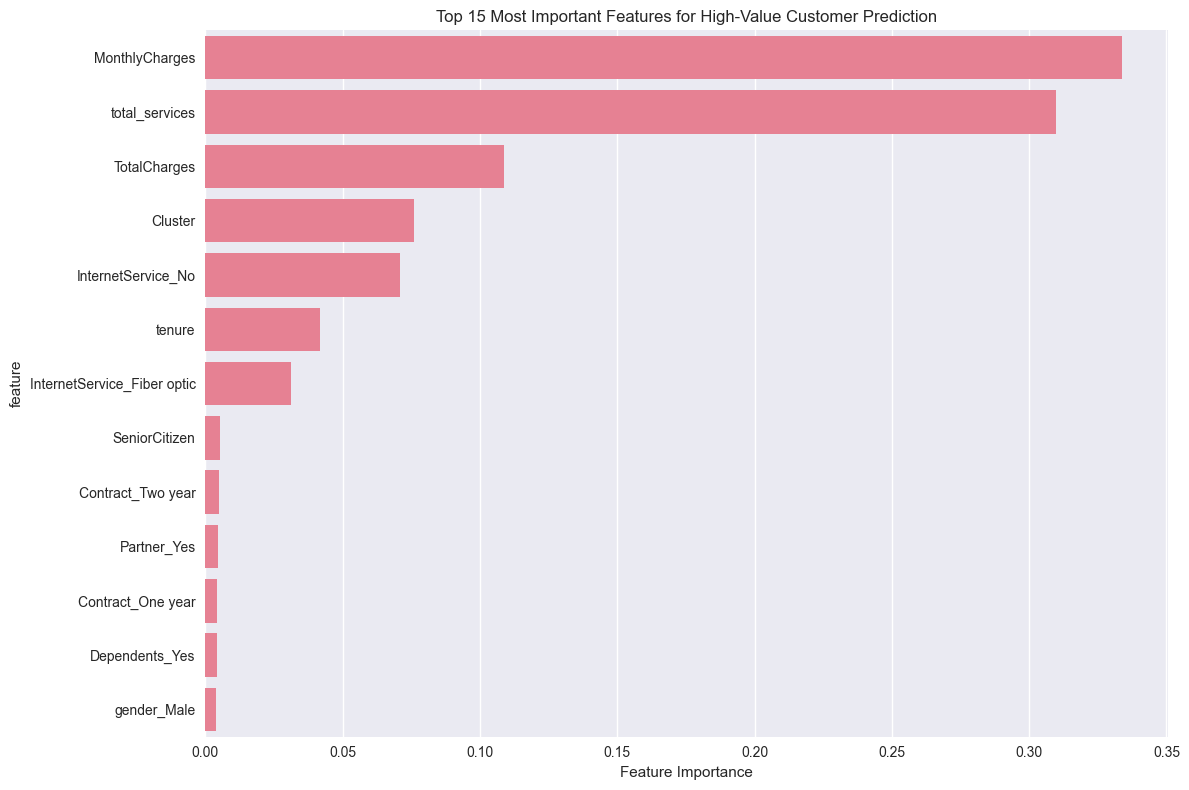

Top 10 Most Important Features:


,feature,importance
1,MonthlyCharges,0.333817
4,total_services,0.309811
2,TotalCharges,0.108817
5,Cluster,0.076183
12,InternetService_No,0.070828
0,tenure,0.041778
11,InternetService_Fiber optic,0.031149
3,SeniorCitizen,0.005284
10,Contract_Two year,0.004910
7,Partner_Yes,0.004804


In [25]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), y='feature', x='importance')
plt.title('Top 15 Most Important Features for High-Value Customer Prediction')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('../visualizations/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 Most Important Features:")
display(feature_importance.head(10))

## 9. Business Insights and Cluster Interpretation

In [26]:
# Generate detailed cluster profiles for business insights
def generate_cluster_insights(df, cluster_col='Cluster'):
    """Generate business insights for each cluster"""
    
    insights = {}
    
    for cluster in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster]
        
        insights[cluster] = {
            'size': len(cluster_data),
            'percentage': len(cluster_data) / len(df) * 100,
            'avg_tenure': cluster_data['tenure'].mean(),
            'avg_monthly_charges': cluster_data['MonthlyCharges'].mean(),
            'avg_total_charges': cluster_data['TotalCharges'].mean(),
            'churn_rate': (cluster_data['Churn'] == 'Yes').mean() * 100,
            'senior_citizen_rate': cluster_data['SeniorCitizen'].mean() * 100,
            'partner_rate': (cluster_data['Partner'] == 'Yes').mean() * 100,
            'dependents_rate': (cluster_data['Dependents'] == 'Yes').mean() * 100,
            'internet_fiber': (cluster_data['InternetService'] == 'Fiber optic').mean() * 100,
            'internet_dsl': (cluster_data['InternetService'] == 'DSL').mean() * 100,
            'no_internet': (cluster_data['InternetService'] == 'No').mean() * 100,
            'monthly_contract': (cluster_data['Contract'] == 'Month-to-month').mean() * 100,
            'one_year_contract': (cluster_data['Contract'] == 'One year').mean() * 100,
            'two_year_contract': (cluster_data['Contract'] == 'Two year').mean() * 100,
            'avg_total_services': cluster_data['total_services'].mean(),
            'streaming_tv': (cluster_data['StreamingTV'] == 'Yes').mean() * 100,
            'streaming_movies': (cluster_data['StreamingMovies'] == 'Yes').mean() * 100,
            'high_value_rate': cluster_data['high_value_customer'].mean() * 100
        }
    
    return insights

cluster_insights = generate_cluster_insights(df_model)

# Display insights in a formatted way
print("=" * 80)
print("DETAILED CLUSTER BUSINESS INSIGHTS")
print("=" * 80)

for cluster, data in cluster_insights.items():
    print(f"\n📊 CLUSTER {cluster} ({data['size']} customers, {data['percentage']:.1f}% of total)")
    print("-" * 60)
    print(f"💰 Financial Profile:")
    print(f"   • Average Monthly Charges: ${data['avg_monthly_charges']:.2f}")
    print(f"   • Average Total Charges: ${data['avg_total_charges']:.2f}")
    print(f"   • Average Tenure: {data['avg_tenure']:.1f} months")
    
    print(f"\n👥 Demographics:")
    print(f"   • Senior Citizens: {data['senior_citizen_rate']:.1f}%")
    print(f"   • Have Partner: {data['partner_rate']:.1f}%")
    print(f"   • Have Dependents: {data['dependents_rate']:.1f}%")
    
    print(f"\n📱 Service Usage:")
    print(f"   • Fiber Optic Internet: {data['internet_fiber']:.1f}%")
    print(f"   • DSL Internet: {data['internet_dsl']:.1f}%")
    print(f"   • No Internet: {data['no_internet']:.1f}%")
    print(f"   • Average Services: {data['avg_total_services']:.1f}")
    print(f"   • Streaming TV: {data['streaming_tv']:.1f}%")
    print(f"   • Streaming Movies: {data['streaming_movies']:.1f}%")
    
    print(f"\n📋 Contract & Loyalty:")
    print(f"   • Month-to-month: {data['monthly_contract']:.1f}%")
    print(f"   • One Year: {data['one_year_contract']:.1f}%")
    print(f"   • Two Year: {data['two_year_contract']:.1f}%")
    print(f"   • Churn Rate: {data['churn_rate']:.1f}%")
    
    print(f"\n🎯 Business Value:")
    print(f"   • High-Value Customer Rate: {data['high_value_rate']:.1f}%")
    print("\n" + "=" * 60)

DETAILED CLUSTER BUSINESS INSIGHTS

📊 CLUSTER 0 (682 customers, 9.7% of total)
------------------------------------------------------------
💰 Financial Profile:
   • Average Monthly Charges: $42.03
   • Average Total Charges: $1496.03
   • Average Tenure: 31.7 months

👥 Demographics:
   • Senior Citizens: 15.2%
   • Have Partner: 45.6%
   • Have Dependents: 30.2%

📱 Service Usage:
   • Fiber Optic Internet: 0.0%
   • DSL Internet: 100.0%
   • No Internet: 0.0%
   • Average Services: 3.6
   • Streaming TV: 41.8%
   • Streaming Movies: 43.7%

📋 Contract & Loyalty:
   • Month-to-month: 55.1%
   • One Year: 21.3%
   • Two Year: 23.6%
   • Churn Rate: 24.9%

🎯 Business Value:
   • High-Value Customer Rate: 56.2%


📊 CLUSTER 1 (1526 customers, 21.7% of total)
------------------------------------------------------------
💰 Financial Profile:
   • Average Monthly Charges: $21.08
   • Average Total Charges: $662.60
   • Average Tenure: 30.5 months

👥 Demographics:
   • Senior Citizens: 3.4%
   •

## 10. Business Recommendations and Strategy

In [27]:
# Create a comprehensive recommendations report
def create_business_recommendations(insights):
    """Generate business recommendations based on cluster analysis"""
    
    recommendations = {}
    
    # Analyze each cluster and provide specific recommendations
    for cluster, data in insights.items():
        recs = []
        
        # Revenue-based recommendations
        if data['avg_monthly_charges'] > 70:
            recs.append("🏆 Premium segment - Focus on retention with VIP treatment")
        elif data['avg_monthly_charges'] < 40:
            recs.append("📈 Low-revenue segment - Upselling opportunity")
        
        # Churn-based recommendations
        if data['churn_rate'] > 30:
            recs.append("⚠️ High churn risk - Implement retention campaigns")
        elif data['churn_rate'] < 15:
            recs.append("✅ Low churn - Stable segment for cross-selling")
        
        # Service adoption recommendations
        if data['avg_total_services'] < 3:
            recs.append("📊 Low service adoption - Target for bundling offers")
        
        # Contract recommendations
        if data['monthly_contract'] > 50:
            recs.append("📝 High month-to-month - Offer long-term contract incentives")
        
        # Internet service recommendations
        if data['internet_dsl'] > data['internet_fiber'] and data['internet_dsl'] > 50:
            recs.append("🚀 DSL dominant - Promote fiber optic upgrades")
        
        # Demographics-based recommendations
        if data['senior_citizen_rate'] > 30:
            recs.append("👴 Senior-heavy segment - Tailor senior-friendly services")
        
        # Streaming services recommendations
        if data['streaming_tv'] < 30 and data['internet_fiber'] > 40:
            recs.append("📺 Low streaming adoption with fiber - Promote streaming packages")
        
        recommendations[cluster] = recs
    
    return recommendations

business_recs = create_business_recommendations(cluster_insights)

print("=" * 80)
print("🎯 TARGETED BUSINESS RECOMMENDATIONS BY CUSTOMER SEGMENT")
print("=" * 80)

for cluster, recs in business_recs.items():
    data = cluster_insights[cluster]
    print(f"\nCLUSTER {cluster} STRATEGY ({data['size']} customers):")
    print("-" * 50)
    for i, rec in enumerate(recs, 1):
        print(f"{i}. {rec}")
    print()

🎯 TARGETED BUSINESS RECOMMENDATIONS BY CUSTOMER SEGMENT

CLUSTER 0 STRATEGY (682 customers):
--------------------------------------------------
1. 📝 High month-to-month - Offer long-term contract incentives
2. 🚀 DSL dominant - Promote fiber optic upgrades


CLUSTER 1 STRATEGY (1526 customers):
--------------------------------------------------
1. 📈 Low-revenue segment - Upselling opportunity
2. ✅ Low churn - Stable segment for cross-selling
3. 📊 Low service adoption - Target for bundling offers


CLUSTER 2 STRATEGY (2149 customers):
--------------------------------------------------
1. 🏆 Premium segment - Focus on retention with VIP treatment


CLUSTER 3 STRATEGY (2686 customers):
--------------------------------------------------
1. 🏆 Premium segment - Focus on retention with VIP treatment
2. ⚠️ High churn risk - Implement retention campaigns
3. 📝 High month-to-month - Offer long-term contract incentives



In [28]:
# Save cluster assignments and predictions for business use
df_final = df_model.copy()
df_final['predicted_high_value'] = rf_model.predict(X)
df_final['high_value_probability'] = rf_model.predict_proba(X)[:, 1]

# Create priority scoring
df_final['priority_score'] = (
    df_final['high_value_probability'] * 0.4 +  # Likelihood of being high-value
    (df_final['MonthlyCharges'] / df_final['MonthlyCharges'].max()) * 0.3 +  # Revenue potential
    (1 - (df_final['Churn'] == 'Yes').astype(int)) * 0.3  # Retention likelihood
)

# Save results
df_final[['customerID', 'Cluster', 'predicted_high_value', 'high_value_probability', 'priority_score']].to_csv(
    '../data/customer_segments_with_predictions.csv', index=False
)

print("Results saved to: ../data/customer_segments_with_predictions.csv")
print(f"\nTop 10 Priority Customers for Upselling:")
display(df_final.nlargest(10, 'priority_score')[['customerID', 'Cluster', 'MonthlyCharges', 
                                                 'tenure', 'high_value_probability', 'priority_score']])

Results saved to: ../data/customer_segments_with_predictions.csv

Top 10 Priority Customers for Upselling:


,customerID,Cluster,MonthlyCharges,tenure,high_value_probability,priority_score
2115,8984-HPEMB,2,118.65,71,0.999465,0.999533
4586,7569-NMZYQ,2,118.75,72,0.998594,0.999437
4804,5734-EJKXG,2,118.60,61,0.999485,0.999415
3894,5989-AXPUC,2,118.60,68,0.997292,0.998538
6118,9924-JPRMC,2,118.20,72,0.999232,0.998303
3205,3810-DVDQQ,2,117.60,72,0.998594,0.996532
4155,6904-JLBGY,2,117.35,72,0.999894,0.996421
6768,9739-JLPQJ,2,117.50,72,0.998594,0.996280
3299,4282-MSACW,2,117.20,68,0.999252,0.995785
2368,6650-BWFRT,2,117.15,72,0.997054,0.994780
